# 機械学習におけるデータ表現の基礎

このノートブックでは、機械学習で扱う「画像」や「文字」などのデータが、どのように数値として表現されるのかを初歩から解説する。

---

## 画像データの数値表現（白黒画像）

白黒画像（グレースケール画像）は、各ピクセルが「明るさ（輝度）」を表す値で構成される。

- 画像は2次元の格子（配列）として表現される。
- 各ピクセルは0〜255の整数値（8ビット）で表されることが多い。
    - 0: 黒
    - 255: 白
    - その間の値: 灰色の濃淡

### 例：3×3ピクセルの白黒画像

グレースケールの画像は、次のような2次元配列（行列）として数値で表現できる。
実際に、`numpy.ndarray`でピクセル値を作成して、白黒画像を表示してみよう。

(-0.5, 2.5, 2.5, -0.5)

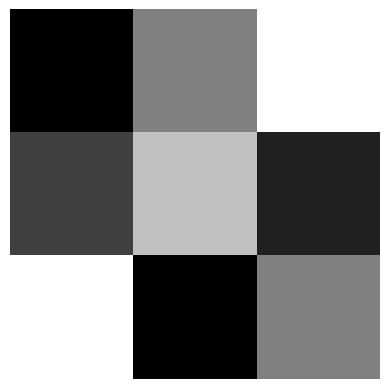

In [1]:
# 3x3の白黒画像を2次元配列で表現
import numpy as np
import matplotlib.pyplot as plt

gray_image = np.array([
    [0, 128, 255],
    [64, 192, 32],
    [255, 0, 128]
])

# 画像を表示
plt.imshow(gray_image, cmap='gray', vmin=0, vmax=255)
plt.axis('off') 

---

## 画像データの数値表現（カラー画像）

カラー画像は、各ピクセルが「赤（R）」「緑（G）」「青（B）」の3つの成分で表現される。

- 各ピクセルは3つの値（R, G, B）を持つ。
- 画像全体は「高さ×幅×3（色）」の3次元配列になる。
- 各成分は0〜255の整数値で表されることが多い。

### 例：2×2ピクセルのカラー画像

| ピクセル位置 (行・列番号) | R | G | B |
|:---:|:---:|:---:|:---:|
| (0,0) | 255 | 0   | 0   |  # 赤
| (0,1) | 0   | 255 | 0   |  # 緑
| (1,0) | 0   | 0   | 255 |  # 青
| (1,1) | 255 | 255 | 0   |  # 黄

このような画像は、次のような3次元配列で表現される。


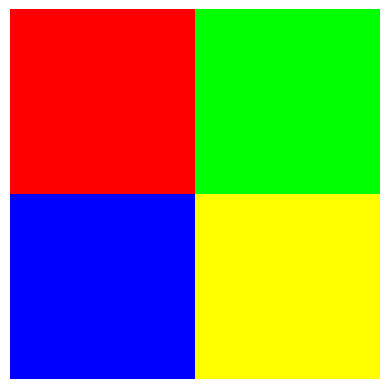

In [2]:
# 2x2のカラー画像を3次元配列で表現
color_image = np.array([
    [[255, 0, 0], [0, 255, 0]],   # 1行目: 赤, 緑
    [[0, 0, 255], [255, 255, 0]]  # 2行目: 青, 黄
])
plt.imshow(color_image)
plt.axis('off') 
plt.show()

`````{admonition} 問題:
:class: attention

$n \times n$の行列で与えられる白黒画像や、$n \times n \times 3$のテンソルで与えられるカラー(RGB)画像データを、
$d$次元のベクトルに変換する関数と、与えられたベクトルから元の画像データに変換するPython自作関数を作ってみよう。


`````

## 画像データの処理

以下では、Pythonの`numpy`などを使って、写真データを数値として読み込んで表示したり、特定の色を抑えるなどの処置をしてみよう。

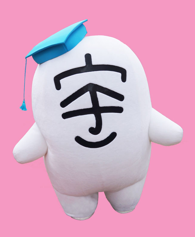

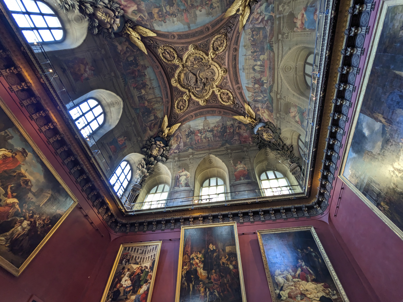

In [3]:
from io import BytesIO
from IPython.display import display
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import requests
url1 = "https://raw.githubusercontent.com/SotaYoshida/Lecture_DataScience/main/notebooks/pic_for_notebook/u_ta.jpeg"
url2 = "https://raw.githubusercontent.com/SotaYoshida/AIML1/main/notebooks/pic/pic_Louvre.jpg"
img1 = Image.open(BytesIO(requests.get(url1).content))
img2 = Image.open(BytesIO(requests.get(url2).content))
img1_ = img1.resize( (int(img1.width*0.3), int(img1.height*0.3)) )
img2_ = img2.resize( (int(img2.width*0.1), int(img2.height*0.1)) )
display(img1_, img2_)

:::{margin}
宇〜太の写真の講義資料での使用は許可を得ています。
:::
それぞれ宇〜太の写真と、ルーブル美術館で撮影した天井の写真である。

In [4]:
img1_array = np.array(img1)
img2_array = np.array(img2)
print("宇〜太の写真のデータ形状:", img1_array.shape)
print("ルーブル美術館の天井写真のデータ形状:", img2_array.shape)

宇〜太の写真のデータ形状: (790, 650, 3)
ルーブル美術館の天井写真のデータ形状: (3024, 4032, 3)


画像データの形状（高さ、幅、色チャネル数）を確認し、最後の成分ごとに頻度を描いてみると、各色の分布がわかる。

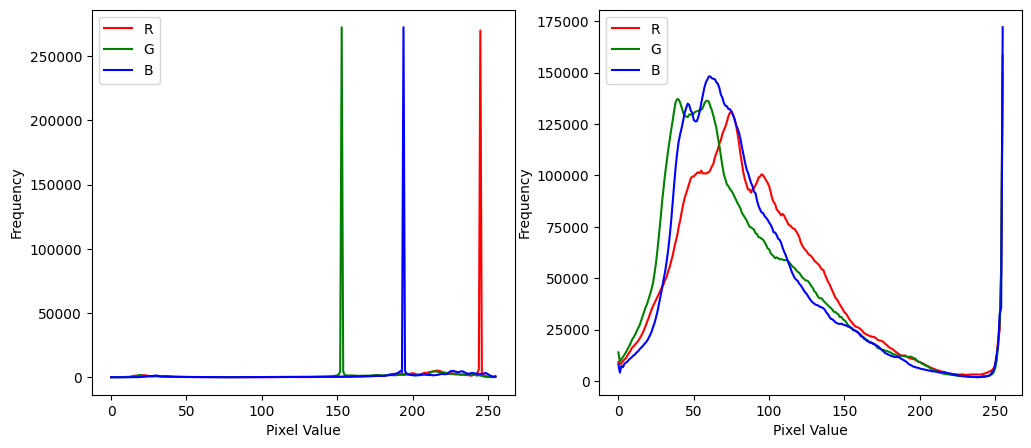

In [5]:
def draw_RGB(image_array):
    R = image_array[:, :, 0].flatten()
    G = image_array[:, :, 1].flatten()
    B = image_array[:, :, 2].flatten()
    hist_R, _ = np.histogram(R, bins=256, range=(0, 255))
    hist_G, _ = np.histogram(G, bins=256, range=(0, 255))
    hist_B, _ = np.histogram(B, bins=256, range=(0, 255))
    return hist_R, hist_G, hist_B

fig = plt.figure(figsize=(12, 5))
axs = [ fig.add_subplot(121), fig.add_subplot(122) ]
for ax, img_array, title in zip(axs, [img1_array, img2_array], ['宇〜太の写真', 'ルーブル美術館の天井写真']):
    hist_R, hist_G, hist_B = draw_RGB(img_array)
    ax.plot(hist_R, color='red', label='R')
    ax.plot(hist_G, color='green', label='G')
    ax.plot(hist_B, color='blue', label='B')
    ax.set_xlabel('Pixel Value')
    ax.set_ylabel('Frequency')
    ax.legend()
plt.show()
plt.close()

宇〜太については、鋭いピークになっていて、特定の色が多いことがわかる。
ルーブル美術館の天井写真については、比較的均一に分布していることが見て取れる。

それぞれの画像について、緑&青の抑制と、赤の抑制をしてみると...

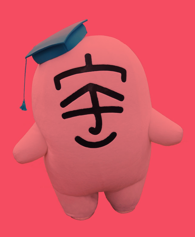

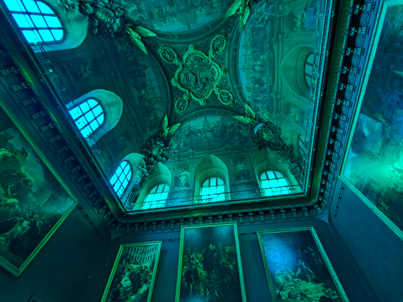

In [6]:
img1_array_modified = np.array(img1_)
img1_array_modified[:, :, (1,2)] //= 2
img2_array_modified = np.array(img2_)
img2_array_modified[:, :, 0] *= 0
display(Image.fromarray(img1_array_modified.astype(np.uint8)))
display(Image.fromarray(img2_array_modified.astype(np.uint8)))

画像編集の際のフィルターはもう少し複雑な操作になるが、基本的な考え方は同じである。

---

## 文字データの数値表現 (bit列との対応関係)

最も単純に文字を数値で表現する方法は、各文字に一意の整数を割り当てる方法である。  
例:
- A → 1
- B → 2
- C → 3
- Z → 26

大文字のアルファベットだけなら、1から26までの整数で表現できる。0か1をとるビットで表現するには、5ビットあれば十分である（2^5 = 32通り）。
対応関係は、右側のbitを1の位、左側に行くほど桁が上がると考えると、次のように表現することができる(ただし、別にこれが唯一の表現方法というわけではない)。

- A: 00001 = 1 (10進数)
- B: 00010 = 2 (10進数)
- C: 00011 = 3 (10進数)
- Z: 11010 = 26 (10進数)

右側から$n$桁目のbitが1であれば、$2^{n-1}$を足し合わせたものが10進数での値になる。


実際には、古くから使われているASCIIコードや、より多くの文字を表現できるUnicodeなどがある。
対応表が異なれば、同じ文字でも異なる数値になるため、文字化けの原因になることがある。
よく、csvファイルをテキストエディタやExcelなどのソフトウェアで開いたときに、文字化けして大量の糸偏の漢字が表示されることがあるが、これは文字コードの対応表が異なるために起こる現象である。


## 文字データの数値表現（埋め込みベクトルの概要）

上記のようなbit列との対応関係は、単純で分かりやすいが、より高度な自然言語処理にはビット数を増やすだけでは十分ではない。
というのも、例えば日本語の全ての単語をデータベース化して対応する整数を割り当てたとして、
「大学」と「大学院」が近い意味を持つことを、整数の大小関係や距離で表現することはできない。
単語の数が少なければまだしも、数十万語にもなると、整数の割り当てだけでは意味的な関係を表現できない。

特定の単語が他の単語とどれくらい意味的に近いか、あるいは文脈的に似ているかを数値で表現するには、**埋め込みベクトル（word embedding）** という方法が用いられる。

- 例：2次元の埋め込みベクトル
    - king → [0.8, 0.6]
    - queen → [0.7, 0.7]
    - apple → [0.1, 0.9]

このようなベクトル表現では、「意味が近い単語ほどベクトルの距離が近い」などの性質を持たせることができる。
要するに、それぞれの単語を$K$次元のベクトル空間にマッピングすることで、意味的な関係を捉えやすくする訳だ。
単に整数を割り当てる場合は、1次元の空間にマッピングしているのと同じであり、意味的な関係を表現するには不十分であるとも言える。

In [7]:
# 単語の埋め込みベクトル例 (あくまでかなり簡略化した例)
embedding = {
    'king':   [0.8, 0.6],
    'queen':  [0.7, 0.7],
    'apple':  [0.1, 0.9]
}

print("king-queenの距離:", np.linalg.norm(np.array(embedding['king']) - np.array(embedding['queen'])))
print("king-appleの距離:", np.linalg.norm(np.array(embedding['king']) - np.array(embedding['apple'])))
print("queen-appleの距離:", np.linalg.norm(np.array(embedding['queen']) - np.array(embedding['apple'])))

king-queenの距離: 0.14142135623730956
king-appleの距離: 0.761577310586391
queen-appleの距離: 0.6324555320336759


実際の埋め込みベクトルはもっと高次元で表現・学習される。

こうした単語の埋め込みベクトルとして有名なものにGoogleが2013年に作成・公開した`Word2Vec`などがある。
コーパス（大量の文章データ）を数百程度の次元のベクトルに変換し、意味的に近い単語ほどベクトル空間上で近くなるように学習する。


ただし、より高度な自然言語処理には、埋め込みベクトル(決まった次元の空間でのベクトル表現)だけでは十分ではない場合がある。
というのも、単語の持つ意味は文脈によって変わることがあるからである。例を示そう。

- 「吉田は大学で物理を学んでいる。」
- 「ピ●チュウは物理よりで育ててるんだよね。」

:::{margin}
ここでの距離の大小はあくまで例示である。「物理」と「文学」は必ずしも距離が遠いとは限らない。例えば寺田寅彦は物理学者であると同時に俳人でもある。
:::
前者の「物理」は物理学の意味であり、「化学」「生物」「宇宙」などと距離が近く、「文学」などと距離が遠いかもしれない。
一方で、後者の「物理」は物理攻撃の意味であり、「攻撃」「ダメージ」などゲーム用語と意味合いが近く、「魔法」「特殊」などと若干距離が遠いかもしれない。


こうした文脈を捉えるうえでは、単語の埋め込みベクトルを文脈に応じて動的に変化させる手法が必要になり、Attention機構などが有効であることが知られている。その最たる例が、大規模言語モデル(LLM)である。

## データのスケーリング

上記のように、様々なデータを数値で表現できる例は挙げたが、実際に機械学習で扱う際には、データのスケール・分布が重要になる場合が多い。
というのも、あらかじめ決めた規則に従ってデータを数値化しても、データのスケール(≒数値の範囲や分布)が異なると、機械学習モデルの学習がうまくいかないことがあるからである。

例えば上の画像データの例で、白黒画像のピクセル値は0〜255の範囲であるが、もし別のデータセットでピクセル値が限られた範囲で表現されている場合(つまり、人間には分かりにくい僅かな濃淡だけがある場合)、これらをそのまま同じモデルで学習させると、うまくいかないことがある。
その僅かな濃淡をもとに、例えばレントゲン写真から病理診断を行うと仮定した場合、ピクセル値の範囲が狭いと、モデルがその違いを学習しづらくなる可能性がある。

多くの機械学習モデルでは、データのスケールを揃えるために、データの平均を0、標準偏差を1にする **標準化（Standardization）** などと呼ばれる手法が用いられる。

ただしこれも万能ではなく、場合によってはデータの特徴を損なうこともあるため、注意が必要である。
例えば、画像データで極端に明るい部分や暗い部分がある場合、標準化によってそれらの特徴が薄れてしまうことがある。

## データの次元

機械学習の文脈では、データの持つ **次元(dimension)** が重要になる。
このことを説明するために、以下では 高次元空間を考えることによる利点と、次元が増えることによる困難である **次元の呪い (curse of dimensionality)** について考えることにする。



### 高次元空間を考える利点

何かのデータを数値で表現する際、それに紐づけられた次元が増大することで、データの特徴をより豊かに表現できるようになることがある。人物に紐づけられたデータの説明変数が複数あるほど、その人物の特徴を捉えたり、他の人物との類似性を表現したりすることができるようになる。

例えば、以下のように一次元的に並んだデータを考えてみる。(とりあえず色の違いは気にしないことにする)


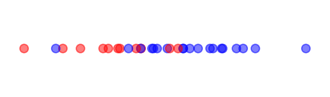

In [28]:
num_p = 30
np.random.seed(40)
x = np.random.normal(70, 12, num_p)
y = np.random.normal(165, 10, num_p)
Data = np.array([x, y])

# 185 = a*45 + b
# 145 = a*90 + b
b = (90*185 - 45*145) / (90 - 45)
a = (145 - b) / 90
xp = np.arange(45, 90, 1)
yp = a*xp + b
cols = [ "r" if a*x[i]+b > y[i] else "b" for i in range(num_p) ]

fig = plt.figure(figsize=(4, 1))
ax = fig.add_subplot(111)
ax.scatter(Data[0], [0]*num_p, color=cols, label='Class 1', alpha=0.5)
# 軸メモリ　線を全てまとめてけす
ax.tick_params(labelbottom=False, labelleft=False,  # 目盛りラベルを消す
               bottom=False, left=False,            # 目盛り線（トゲ）を消す
               right=False, top=False)     
# 囲い線を消す
ax.spines['top'].set_visible(False) 
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.set_ylim(-0.01, 0.01)
plt.show()
plt.close()


一見すると、データがただ一次元的に並んでいるだけのように見えるが、実はこのデータは、ある集団の身長を表しているとする。すると、体重も入れた二次元の図を描いてみることができれば、身長と体重の両方を考慮して、より個人の特徴を捉えることができるようになる。

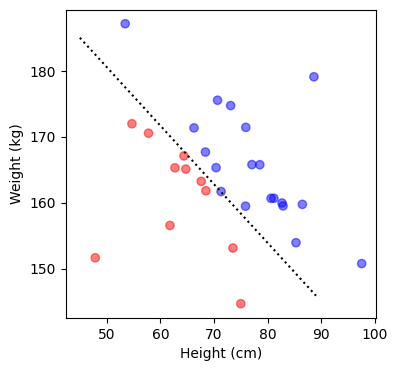

In [32]:
fig = plt.figure(figsize=(4, 4))
ax = fig.add_subplot(111)
ax.plot(xp, yp, color='k', linestyle='dotted')
ax.scatter(Data[0], Data[1], color=cols, label='Class 1', alpha=0.5)
ax.set_xlabel('Height (cm)')
ax.set_ylabel('Weight (kg)')
plt.show()
plt.close()

体格の大きい人と体格の小さい人を区別することができる。これは非常にシンプルな例であるが、このように、次元が増えることで、データの特徴をより豊かに表現できるようになることがある。

もちろん、逆もまた然りで、冗長なデータを追加しても、必ずしもデータの特徴を豊かに表現できるようになるとは限らない。例えば、身長と体重の両方を考慮することは有用であるが、身長と体重の両方を考慮した上で、さらに身長(m単位)を追加しても意味がないどころか、冗長なデータを追加することで、モデルの学習がうまくいかなくなることもある。

### 次元の呪い (curse of dimensionality)

データや確率分布の次元が増えると、データの特徴を豊かに表現できるようになる一方で、次元が増えることによる困難も生じることがある。
このことを指してよく、 **次元の呪い (curse of dimensionality)** という言葉が使われる。

機械学習の大規模モデルはもちろん、計算科学が対象とするありとあらゆる分野・問題で、次元の呪いは避けて通れない問題である。


プログラムの学習をする際の鉄板の問題として、乱数を生成して円の内部に入った点と外に出た点を数えることで、円周率を近似する方法がある。
例えば、$x_1$と$x_2$を$-r$から$r$の範囲で無作為にサンプルすると、点$(x_1, x_2)$は単位正方形の中にランダムに配置されることになる。

この辺$2r$の正方形の面積は、$4r^2$で、その中に内接する半径$r$の円の面積は、$\pi r^2$であることから、上述の点が円の内部に入る確率は、$\pi r^2 / 4r^2 = \pi / 4$であることがわかる。

では、次元が増えるとどうなるだろうか。
1つ次元を増やすと、正方形/単位円はそれぞれ立方体/単位球になる。
さらに次元を増やすと、超立方体に内接する超球を考えることになる。

N次元の一片の長さが$2r$である超立方体の体積、
半径が$r$であるN次元の超球の体積はそれぞれ次のように表される。

$$
\begin{align*}
V_{cube} & = (2r)^N \\
V_{sphere} & = \frac{\pi^{N/2}}{\Gamma(N/2 + 1)} r^N
\end{align*}
$$

ここで、$\Gamma$はガンマ関数である。
このとき、点が超球の内部に入る確率は、次のように表される。

$$
P = \frac{V_{sphere}}{V_{cube}} = \frac{\pi^{N/2}}{\Gamma(N/2 + 1) 2^N}
$$

ガンマ関数は、$N/2 + 1$が整数のときは、$(N/2)!$と同じ値を取ることが知られているため、大きな$N$のときは、超立方体に占める超球の割合はものすごく小さくなることがわかる。

$r=1$として、次元数$N$に具体的な数を入れて確かめてみよう。

In [37]:
def factorial(n):
    if n == 0:
        return 1
    else:
        return n * factorial(n-1)

r = 1.0
for N in range(2, 22, 4):
    P = np.pi**(N/2) * r**N / ( factorial(N/2) * 2**(N))
    print(f"N={N:2d}: P = {P:.2e}")

N= 2: P = 7.85e-01
N= 6: P = 8.07e-02
N=10: P = 2.49e-03
N=14: P = 3.66e-05
N=18: P = 3.13e-07
